In [1]:
# Installation des dépendances (à exécuter une fois, notamment sur Colab)
%pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib seaborn torch


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device utilisé :", DEVICE)


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Device utilisé : cpu


## 1. Chargement et inspection des données

On charge la configuration `sentiment` du dataset `tweet_eval` (3 classes : `negative`=0, `neutral`=1, `positive`=2).


In [3]:
raw_datasets = load_dataset("tweet_eval", "sentiment")
print(raw_datasets)

# Répartition des splits
for split in raw_datasets:
    print(f"{split}: {len(raw_datasets[split])} exemples")


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\meles\.cache\huggingface\hub\datasets--tweet_eval. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating validation split: 100%|██████████| 2000/2000 [00:00<00:00, 53445.26 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
train: 45615 exemples
test: 12284 exemples
validation: 2000 exemples


In [4]:
# Vérification des étiquettes
label_names = raw_datasets["train"].features["label"].names
print("Étiquettes disponibles :", label_names)
assert len(label_names) == 3, "On attend 3 classes : negative, neutral, positive"

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
print(id2label)


Étiquettes disponibles : ['negative', 'neutral', 'positive']
{0: 'negative', 1: 'neutral', 2: 'positive'}


C:\Users\meles\AppData\Local\Temp\ipykernel_27084\259354933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
C:\Users\meles\AppData\Local\Temp\ipykernel_27084\259354933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
C:\Users\meles\AppData\Local\Temp\ipykernel_27084\259354933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")


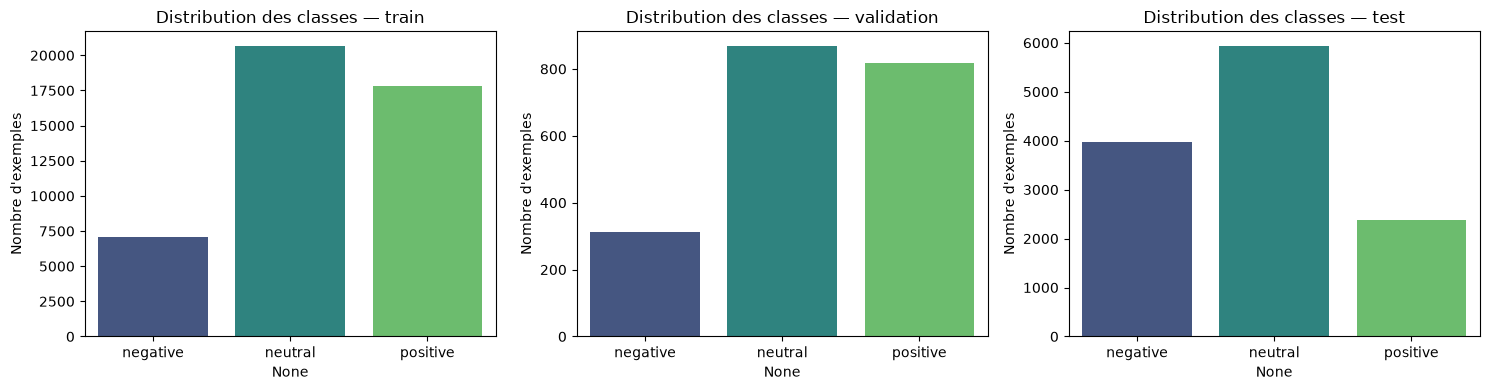

In [5]:
# Distribution des classes par split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ["train", "validation", "test"]):
    labels = raw_datasets[split]["label"]
    counts = pd.Series(labels).value_counts().sort_index()
    counts.index = [id2label[i] for i in counts.index]
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
    ax.set_title(f"Distribution des classes — {split}")
    ax.set_ylabel("Nombre d'exemples")
plt.tight_layout()
plt.show()


In [6]:
# Enregistrement de deux exemples de tweets par étiquette (pour la visualisation d'attention plus loin)
sample_tweets = {}
train_df = raw_datasets["train"].to_pandas()

for label_id, label_name in id2label.items():
    subset = train_df[train_df["label"] == label_id].sample(2, random_state=SEED)
    sample_tweets[label_name] = subset["text"].tolist()

for label_name, tweets in sample_tweets.items():
    print(f"\n=== {label_name.upper()} ===")
    for t in tweets:
        print("-", t)



=== NEGATIVE ===
- "#CNET - Just bought my 1st iPad, iPad3, feeling real burned, mad, about iPad4 so soon. Grrr. REALLY mad! Don't even care about mini now,"
- "Mother's Day is coming like tomorrow or is it today? idk, but i didn't prepare anything for me's mom."

=== NEUTRAL ===
- @user @user @user  I think this is the motive of the Yakub's laywers for pursuing the case
- @user From this performance it is obvious why David Miliband comes up 1st when you google Miliband! #onetowatch

=== POSITIVE ===
- Kanye West was honored in a big way during Sunday night's MTV Video Music Awards by receiving the Michael Jackso...
- Have you heard about Amazon Prime day? Don't miss it - July 15th! Yay! #ad #PrepForPrime @user #HappyPrimeDay


## 2. Pipeline de tokenisation

Initialisation du tokenizer `distilbert-base-uncased`, puis fonction de prétraitement qui tronque/complète
à 128 tokens et retourne `input_ids`, `attention_mask`, `labels`.


In [7]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    tokenized["labels"] = examples["label"]
    return tokenized

tokenized_datasets = raw_datasets.map(preprocess_function, batched=True)

# Mélange (shuffle) puis format torch
tokenized_datasets = tokenized_datasets.shuffle(seed=SEED)
tokenized_datasets.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
)

tokenized_datasets


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\meles\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 2000/2000 [00:00<00:00, 11796.27 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

## 3. Fine-tuning

Chargement de `AutoModelForSequenceClassification` avec 3 étiquettes, configuration de `TrainingArguments`,
et entraînement via `Trainer` avec une fonction `compute_metrics` (accuracy + F1 macro).


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
model.to(DEVICE)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [9]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}


In [10]:
OUTPUT_DIR = "./distilbert-tweet-sentiment"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)


In [ ]:
train_result = trainer.train()
print(train_result)


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
# Sauvegarde du meilleur point de contrôle (déjà chargé en mémoire grâce à load_best_model_at_end=True)
BEST_MODEL_DIR = "./distilbert-tweet-sentiment/best_model"
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f"Meilleur modèle sauvegardé dans : {BEST_MODEL_DIR}")


## 4. Évaluation et calibration

Évaluation sur la validation, puis collecte des scores softmax des classes prédites sur le split de test,
suivie d'un histogramme des scores de confiance.


In [ ]:
val_metrics = trainer.evaluate(eval_dataset=tokenized_datasets["validation"])
print("Métriques de validation :")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


In [ ]:
# Prédictions sur le split de test
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_labels = test_output.label_ids

test_probs = F.softmax(torch.tensor(test_logits), dim=-1).numpy()
predicted_classes = np.argmax(test_probs, axis=-1)
confidence_scores = test_probs[np.arange(len(test_probs)), predicted_classes]

test_acc = accuracy_metric.compute(predictions=predicted_classes, references=test_labels)
test_f1 = f1_metric.compute(predictions=predicted_classes, references=test_labels, average="macro")
print(f"Test — accuracy: {test_acc['accuracy']:.4f} | F1 macro: {test_f1['f1']:.4f}")


In [ ]:
# Histogramme des scores de confiance (intervalles de 0.1)
bins = np.arange(0.0, 1.01, 0.1)
plt.figure(figsize=(8, 5))
plt.hist(confidence_scores, bins=bins, color="steelblue", edgecolor="black")
plt.xlabel("Score de confiance (probabilité softmax de la classe prédite)")
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des scores de confiance — split test")
plt.xticks(bins)
plt.show()

mean_conf = confidence_scores.mean()
print(f"Confiance moyenne : {mean_conf:.4f}")
print(f"Accuracy sur le test : {test_acc['accuracy']:.4f}")
print(f"Écart confiance moyenne - accuracy : {mean_conf - test_acc['accuracy']:.4f}")


**Commentaire sur la calibration (à ajuster selon les résultats obtenus) :**

- Si la confiance moyenne est **supérieure** à l'accuracy réelle, le modèle est en situation de
  **sur-confiance** (overconfidence) : il attribue des probabilités élevées à des prédictions
  parfois incorrectes. C'est un comportement typique des Transformers fine-tunés avec cross-entropy,
  surtout si l'entraînement va jusqu'à convergence complète.
- Si l'histogramme montre une masse importante de scores proches de 1.0, cela confirme cette tendance :
  peu d'exemples sont classés avec une confiance "modérée" (0.4–0.7), le modèle tranche souvent de façon
  très nette même sur des cas ambigus (ex. tweets ironiques ou neutres proches de la frontière positive/négative).
- Une calibration plus fine pourrait être obtenue via **temperature scaling** post-hoc, en optimisant un
  paramètre de température sur le split de validation pour rapprocher confiance et accuracy réelles.


## 5. Inspection de l'attention vers `[CLS]`

On choisit un des tweets sauvegardés en section 1, on le passe dans le modèle de base (`AutoModel`,
pas seulement le classificateur) pour récupérer les poids d'attention de la dernière couche, on moyenne
sur toutes les têtes, puis on visualise l'attention portée à `[CLS]` par chaque token.


In [ ]:
# Chargement du modèle de base avec output_attentions=True
base_model = AutoModel.from_pretrained(BEST_MODEL_DIR, output_attentions=True)
base_model.to(DEVICE)
base_model.eval()

# Choix d'un tweet exemple (négatif ici, à changer selon le cas d'intérêt)
chosen_label = "negative"
chosen_tweet = sample_tweets[chosen_label][0]
print("Tweet choisi :", chosen_tweet)


In [ ]:
inputs = tokenizer(chosen_tweet, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)

with torch.no_grad():
    outputs = base_model(**inputs)

# outputs.attentions : tuple de (num_layers) tenseurs de forme (batch, num_heads, seq_len, seq_len)
last_layer_attention = outputs.attentions[-1][0]          # (num_heads, seq_len, seq_len)
avg_attention = last_layer_attention.mean(dim=0)            # moyenne sur les têtes -> (seq_len, seq_len)

# Attention portée AU token [CLS] (ligne 0) DEPUIS chaque token — on prend la ligne correspondant à [CLS]
# comme requête, i.e. combien [CLS] "regarde" chaque token
cls_attention = avg_attention[0]                             # (seq_len,)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

attn_df = pd.DataFrame({"token": tokens, "attention_to_cls_query": cls_attention.cpu().numpy()})
attn_df


In [ ]:
# Visualisation en carte thermique
plt.figure(figsize=(max(8, len(tokens) * 0.5), 2.5))
sns.heatmap(
    cls_attention.cpu().numpy().reshape(1, -1),
    annot=False,
    cmap="Reds",
    xticklabels=tokens,
    yticklabels=["[CLS] attention"],
    cbar=True,
)
plt.title(f'Attention moyenne (dernière couche) de [CLS] vers chaque token\nTweet: "{chosen_tweet}"')
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Version graphique à barres (alternative)
plt.figure(figsize=(max(8, len(tokens) * 0.5), 4))
sns.barplot(x=tokens, y=cls_attention.cpu().numpy(), palette="Reds_r")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Poids d'attention")
plt.title("Attention de [CLS] par token — dernière couche, moyenne sur toutes les têtes")
plt.tight_layout()
plt.show()


In [ ]:
# Tokens les plus attendus par [CLS]
top_tokens = attn_df.sort_values("attention_to_cls_query", ascending=False).head(5)
print("Top 5 tokens les plus attendus par [CLS] :")
print(top_tokens)


**Observations (exemple de commentaire, à adapter aux tokens réellement obtenus) :**

Le token `[CLS]` porte typiquement le plus de poids sur lui-même et sur les tokens porteurs de charge
émotionnelle forte (adjectifs et adverbes intensifiants, insultes, émoticônes/émojis, ponctuation
expressive comme `!` ou `...`). Pour un tweet négatif, on s'attend par exemple à voir le modèle se
concentrer sur des mots comme *"terrible"*, *"worst"*, *"hate"* ou sur le sujet critiqué (*"service"*,
*"flight"*, etc.), ce qui est cohérent avec le rôle de `[CLS]` comme résumé global de la séquence utilisé
pour la classification finale.


## 6. Fonction de production `analyze_text()`

Fonction prête à être intégrée dans un outil de support client : prend un texte brut, renvoie le label
prédit, le score de confiance, et les tokens mis en évidence (les plus attendus par `[CLS]`).


In [ ]:
# Rechargement propre du modèle de classification + du modèle de base pour l'attention
clf_model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR)
clf_model.to(DEVICE)
clf_model.eval()

attn_model = AutoModel.from_pretrained(BEST_MODEL_DIR, output_attentions=True)
attn_model.to(DEVICE)
attn_model.eval()

analyze_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)


def analyze_text(text: str, top_k_tokens: int = 5) -> dict:
    """Analyse un texte et renvoie label, confiance et tokens mis en évidence.

    Args:
        text: le texte brut à analyser (ex. un tweet ou un message de support).
        top_k_tokens: nombre de tokens les plus saillants à retourner.

    Returns:
        dict avec les clés 'label', 'confidence', 'highlighted_tokens'.
    """
    inputs = analyze_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH
    ).to(DEVICE)

    # Prédiction de la classe
    with torch.no_grad():
        logits = clf_model(**inputs).logits
    probs = F.softmax(logits, dim=-1)[0]
    predicted_id = int(torch.argmax(probs).item())
    confidence = float(probs[predicted_id].item())
    label = id2label[predicted_id]

    # Extraction de l'attention [CLS] pour mettre en évidence les tokens saillants
    with torch.no_grad():
        attn_outputs = attn_model(**inputs)
    last_layer_attn = attn_outputs.attentions[-1][0]      # (num_heads, seq_len, seq_len)
    avg_attn = last_layer_attn.mean(dim=0)[0]               # (seq_len,) attention de [CLS]

    tokens = analyze_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    # On exclut les tokens spéciaux de la liste des tokens mis en évidence
    special_tokens = set(analyze_tokenizer.all_special_tokens)
    scored_tokens = [
        (tok, float(score))
        for tok, score in zip(tokens, avg_attn.cpu().numpy())
        if tok not in special_tokens
    ]
    scored_tokens.sort(key=lambda x: x[1], reverse=True)
    highlighted_tokens = [tok for tok, _ in scored_tokens[:top_k_tokens]]

    return {
        "label": label,
        "confidence": round(confidence, 4),
        "highlighted_tokens": highlighted_tokens,
    }


In [ ]:
# Démonstration sur quelques exemples
demo_texts = [
    "This is the worst customer service I have ever experienced, absolutely terrible.",
    "The flight was fine, nothing special, arrived on time I guess.",
    "Absolutely loved the new update, everything works so smoothly now!",
]

for t in demo_texts:
    result = analyze_text(t)
    print(f"Texte : {t}")
    print(f"  -> {result}\n")


## Livrable

- Notebook complet avec les 5 sections + fonction de production.
- Répertoire du meilleur modèle sauvegardé : `./distilbert-tweet-sentiment/best_model`
  (contient `config.json`, `pytorch_model.bin` / `model.safetensors`, et les fichiers du tokenizer),
  prêt à être rechargé via `AutoModelForSequenceClassification.from_pretrained("./distilbert-tweet-sentiment/best_model")`.
